In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from vis import make_yref
import os
import globals as gl
from pathlib import Path
from pcm_models import find_model, make_planning_models, make_execution_models
from statsmodels.stats.anova import AnovaRM
import pingouin as pg
from scipy.stats import ttest_1samp, pearsonr, ttest_rel

plt.style.use('default')
ROOT =  Path().resolve().parent

In [11]:
experiment = 'smp2'

In [12]:
from vis import demographics
_ = demographics(experiment)

Total Participants: 14
Gender Distribution: sex
m    8
f    6
Name: count, dtype: int64
Average Age: 21.357142857142858
SD Age: 4.162232072359232
Age Range: (np.int64(18), np.int64(34))
Handedness Distribution: handedness
right    14
Name: count, dtype: int64


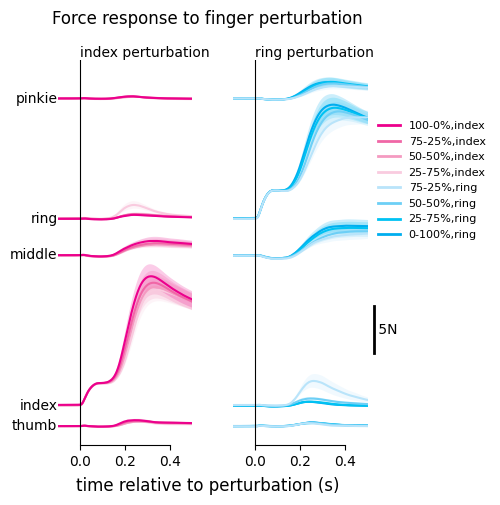

In [13]:
from vis import plot_aligned_force

npz = np.load(os.path.join(ROOT, 'data', gl.behavDir, 'force.segmented.avg.npz'), allow_pickle=True)
force = npz['data_array']
descr = pd.DataFrame(npz['descriptor'].item())
force = force[descr.GoNogo == 'go']
descr = descr[descr.GoNogo == 'go']
fig, axs = plt.subplots(1, 2, figsize=(4, 5), sharey=True, sharex=True)
plot_aligned_force(fig, axs, force, descr)
plt.show()

In [14]:
filepath = os.path.join(ROOT, 'data', gl.behavDir, f'{experiment}_force_single_trial.tsv')
dat = pd.read_csv(filepath, sep='\t', )
dat = dat.groupby(['sn', 'GoNogo']).mean(numeric_only=True).reset_index()
RT = dat[dat['GoNogo']=='go'].RT
print(f'RT={RT.mean()}+/-{RT.std()}')

RT=0.16297010738886744+/-0.02124454320570604


rmANOVA index
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue 21.1345 3.0000 39.0000 0.0000

rmANOVA ring
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  6.1095 3.0000 39.0000 0.0016



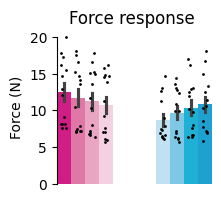

In [15]:
from vis import plot_binned_behaviour

fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))
filepath = os.path.join(ROOT, 'data', gl.behavDir, f'{experiment}_force_single_trial.tsv')
dat = pd.read_csv(filepath, sep='\t', )
dat = dat.groupby(['sn', 'cue', 'stimFinger', 'GoNogo', ]).mean(numeric_only=True).reset_index()
fig, axs = plot_binned_behaviour(fig, axs, dat, y=['index1', 'ring1'], finger=('index', 'ring'))
axs[0].spines[['left']].set_bounds(0, 20)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Force response')

anova_index = AnovaRM(data=dat[dat['stimFinger']=='index'], depvar='index1', subject='sn', within=['cue'])
anova_ring = AnovaRM(data=dat[dat['stimFinger']=='ring'], depvar='ring1', subject='sn', within=['cue'])

result = anova_index.fit()
print('rmANOVA index')
print(result)

result = anova_ring.fit()
print('rmANOVA ring')
print(result)

plt.show()

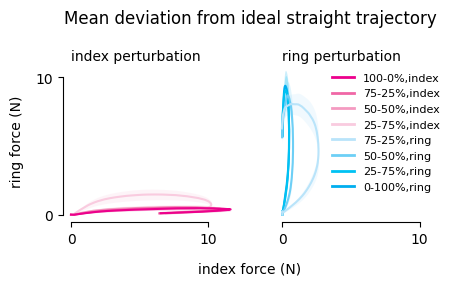

In [16]:
from vis import plot_aligned_deviation

fig, axs = plt.subplots(1, 2, figsize=(5, 2.75), sharey=True, sharex=True)
cut = .06 # skip first 60ms (no active force generated)
startSample = int(gl.prestim * gl.fsample_mov + cut * gl.fsample_mov)
force = force[:, startSample:]
force = force - force[:, 0][:, None]
plot_aligned_deviation(fig, axs, force, descr)

plt.show()

Index---------------------------------------------------
TtestResult(statistic=np.float64(2.743758608452386), pvalue=np.float64(0.008368111434958726), df=np.int64(13))
Ring----------------------------------------------------
TtestResult(statistic=np.float64(3.200504817982011), pvalue=np.float64(0.0034804108473013725), df=np.int64(13))


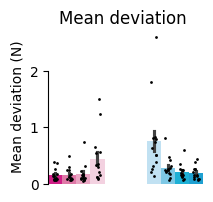

In [17]:
fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))
fig, axs = plot_binned_behaviour(fig, axs, dat, y=['MD', 'MD'], finger=('index', 'ring'))
axs[0].spines[['left']].set_bounds(0, 2)
axs[0].set_ylabel('Mean deviation (N)')

fig.suptitle('Mean deviation')

filepath = os.path.join(gl.baseDir, experiment, gl.behavDir, f'{experiment}_force_single_trial.tsv')
dat_stat = pd.read_csv(filepath, sep='\t', )
dat_stat = dat_stat.groupby(['sn', 'stimFinger', 'Unexpected']).mean(numeric_only=True).reset_index()
dat_stat = dat_stat[dat_stat['Unexpected']>=0]

print('Index---------------------------------------------------')
dat_stat_index = dat_stat[dat_stat['stimFinger']=='index']
x1 = dat_stat_index[dat_stat_index['Unexpected']==1].MD.to_numpy()
x0 = dat_stat_index[dat_stat_index['Unexpected']==0].MD.to_numpy()
print(ttest_1samp(x1 - x0, 0, alternative='greater'))

print('Ring----------------------------------------------------')
dat_stat_index = dat_stat[dat_stat['stimFinger']=='ring']
x1 = dat_stat_index[dat_stat_index['Unexpected']==1].MD.to_numpy()
x0 = dat_stat_index[dat_stat_index['Unexpected']==0].MD.to_numpy()
print(ttest_1samp(x1 - x0, 0, alternative='greater'))

plt.show()

rmANOVA index
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  3.4133 4.0000 52.0000 0.0149

rmANOVA ring
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  6.0417 4.0000 52.0000 0.0005



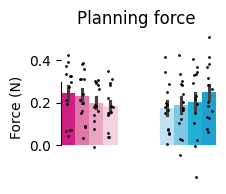

In [18]:
fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))
fig, axs = plot_binned_behaviour(fig, axs, dat, y=['index0', 'ring0'])
axs[0].spines[['left']].set_bounds(0, .3)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Planning force')

anova_index = AnovaRM(data=dat[dat['stimFinger']=='nogo'], depvar='index0', subject='sn', within=['cue'])
anova_ring = AnovaRM(data=dat[dat['stimFinger']=='nogo'], depvar='ring0', subject='sn', within=['cue'])

result = anova_index.fit()
print('rmANOVA index')
print(result)

result = anova_ring.fit()
print('rmANOVA ring')
print(result)

plt.show()